In [1]:
import pandas as pd

df = pd.read_csv("/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/raw/uncleaned-ds-jobs-6992efeeb7cba766418597.csv")


In [2]:
import numpy as np
df = df.replace(-1, np.nan)
df = df.replace("-1", np.nan)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    str    
 2   Salary Estimate    672 non-null    str    
 3   Job Description    672 non-null    str    
 4   Rating             622 non-null    float64
 5   Company Name       672 non-null    str    
 6   Location           672 non-null    str    
 7   Headquarters       641 non-null    str    
 8   Size               645 non-null    str    
 9   Founded            554 non-null    float64
 10  Type of ownership  645 non-null    str    
 11  Industry           601 non-null    str    
 12  Sector             601 non-null    str    
 13  Revenue            645 non-null    str    
 14  Competitors        171 non-null    str    
dtypes: float64(2), int64(1), str(12)
memory usage: 78.9 KB


In [4]:
df.isnull().sum()

index                  0
Job Title              0
Salary Estimate        0
Job Description        0
Rating                50
Company Name           0
Location               0
Headquarters          31
Size                  27
Founded              118
Type of ownership     27
Industry              71
Sector                71
Revenue               27
Competitors          501
dtype: int64

In [5]:
df["Rating"]= df["Rating"].fillna(df["Rating"].median())
df["Founded"]= df["Founded"].fillna("Unkown")
df["Headquarters"]= df["Headquarters"].fillna("Unkown")
df["Size"]= df["Size"].fillna("Unkown")
df["Industry"]= df["Industry"].fillna("Unkown")
df["Sector"]= df["Sector"].fillna("Unkown")





In [6]:
df.isnull().sum()

index                  0
Job Title              0
Salary Estimate        0
Job Description        0
Rating                 0
Company Name           0
Location               0
Headquarters           0
Size                   0
Founded                0
Type of ownership     27
Industry               0
Sector                 0
Revenue               27
Competitors          501
dtype: int64

In [7]:

import re
title= df["Job Title"]

def job_title(title):

    title = title.str.lower()
    title = title.str.replace("sr", "senior", regex=False)
    title = title.str.replace("jr", "junior", regex=False)
    title = title.str.replace("ml", "machine learning", regex=False)
    title = title.str.replace("scientistsmachine", "scientists machine", regex=False)
    title = title.str.replace("  ", "scientists machine", regex=False)
    title = title.str.replace(r"[^\w\s]", "", regex=True)
    return title

df["Job Title"]=job_title(df["Job Title"]) 
    

In [8]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

columns = ["Company Name", "Revenue", "Type of ownership", "Job Description", "Job Title",
           "Rating", "Location", "Headquarters", "Size", "Founded", "Type of ownership",
           "Industry", "Sector", "Revenue", "Competitors"]

stop_words = set(stopwords.words("english"))

for col in columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.lower()
        .str.replace("^&", "", regex=False)
        .str.replace("'", "", regex=False)
        .str.replace("K", "", regex=False)
        .str.replace("\n", "", regex=False)
        .str.replace("/", "", regex=False)
        .str.replace("&", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("#", "", regex=False)
        .str.replace(":", "", regex=False)
        .str.replace("-", "", regex=False)
        .str.replace("_", "", regex=False)
        .str.replace("*", "", regex=False)
        .str.replace("+", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("[", "", regex=False)
        .str.replace("<", "", regex=False)
        .str.replace(">", "", regex=False)
        .str.replace("!", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("?", "", regex=False)
        
    )

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/miriambenali/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:

df["Salary Estimate"]= (
    df["Salary Estimate"]
    .str.replace("Glassdoor est.", "", regex=False)
    .str.replace("Employer est.", "", regex=False)
    .str.replace("()", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("K", "", regex=False)
    
)

In [10]:
df.head(5)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,senior data scientist,137-171,descriptionthe senior data scientist is respon...,3.1,healthfirst3.1,"new york, ny","new york, ny",1001 to 5000 employees,1993.0,nonprofit organization,insurance carriers,insurance,unknown nonapplicable,"emblemhealth, unitedhealth group, aetna"
1,1,data scientist,137-171,"secure our nation, ignite your futurejoin the ...",4.2,mantech4.2,"chantilly, va","herndon, va",5001 to 10000 employees,1968.0,company public,research development,business services,1 to 2 billion usd,NaN
2,2,data scientist,137-171,overviewanalysis group is one of the largest i...,3.8,analysis group3.8,"boston, ma","boston, ma",1001 to 5000 employees,1981.0,private practice firm,consulting,business services,100 to 500 million usd,NaN
3,3,data scientist,137-171,job descriptiondo you have a passion for data ...,3.5,inficon3.5,"newton, ma","bad ragaz, switzerland",501 to 1000 employees,2000.0,company public,electrical electronic manufacturing,manufacturing,100 to 500 million usd,"mks instruments, pfeiffer vacuum, agilent tech..."
4,4,data scientist,137-171,data scientistaffinity solutions marketing cl...,2.9,affinity solutions2.9,"new york, ny","new york, ny",51 to 200 employees,1998.0,company private,advertising marketing,business services,unknown nonapplicable,"commerce signals, cardlytics, yodlee"


In [11]:

def compute_mean_salary(salary):
    min_salary, max_salary = salary.split("-")

    min_salary = float(min_salary)
    max_salary = float(max_salary)

    return (min_salary + max_salary) / 2


In [12]:
df["mean_salary"] = df["Salary Estimate"].apply(compute_mean_salary)

In [13]:
#convertir en dollard
df["mean_salary"] = df["mean_salary"] * 1000

In [14]:
df.head(5)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,mean_salary
0,0,senior data scientist,137-171,descriptionthe senior data scientist is respon...,3.1,healthfirst3.1,"new york, ny","new york, ny",1001 to 5000 employees,1993.0,nonprofit organization,insurance carriers,insurance,unknown nonapplicable,"emblemhealth, unitedhealth group, aetna",154000.0
1,1,data scientist,137-171,"secure our nation, ignite your futurejoin the ...",4.2,mantech4.2,"chantilly, va","herndon, va",5001 to 10000 employees,1968.0,company public,research development,business services,1 to 2 billion usd,NaN,154000.0
2,2,data scientist,137-171,overviewanalysis group is one of the largest i...,3.8,analysis group3.8,"boston, ma","boston, ma",1001 to 5000 employees,1981.0,private practice firm,consulting,business services,100 to 500 million usd,NaN,154000.0
3,3,data scientist,137-171,job descriptiondo you have a passion for data ...,3.5,inficon3.5,"newton, ma","bad ragaz, switzerland",501 to 1000 employees,2000.0,company public,electrical electronic manufacturing,manufacturing,100 to 500 million usd,"mks instruments, pfeiffer vacuum, agilent tech...",154000.0
4,4,data scientist,137-171,data scientistaffinity solutions marketing cl...,2.9,affinity solutions2.9,"new york, ny","new york, ny",51 to 200 employees,1998.0,company private,advertising marketing,business services,unknown nonapplicable,"commerce signals, cardlytics, yodlee",154000.0


In [15]:
import pandas as pd

numeric_cols = ['mean_salary'] 

def outliers(df, numeric_cols):
    result = []

    for col in numeric_cols:
        # Calcul des quantiles
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        # Bornes pour les outliers
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # détecter les outliers
        outlier_rows = df[(df[col] < lower) | (df[col] > upper)]

        # ajouter les résultats
        result.append({
            "column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "Outlier_Count": outlier_rows.shape[0],
            "Outliers": outlier_rows[col].tolist()
        })

    return pd.DataFrame(result)

# Lancer la détection
outliers_df = outliers(df, numeric_cols)
print(outliers_df)

        column        Q1        Q3      IQR  lower_bound  upper_bound  \
0  mean_salary  103000.0  136500.0  33500.0      52750.0     186750.0   

   Outlier_Count                                           Outliers  
0             41  [43500.0, 43500.0, 43500.0, 43500.0, 43500.0, ...  


In [16]:
import numpy as np

df['mean_salary'] = np.log(df['mean_salary'])


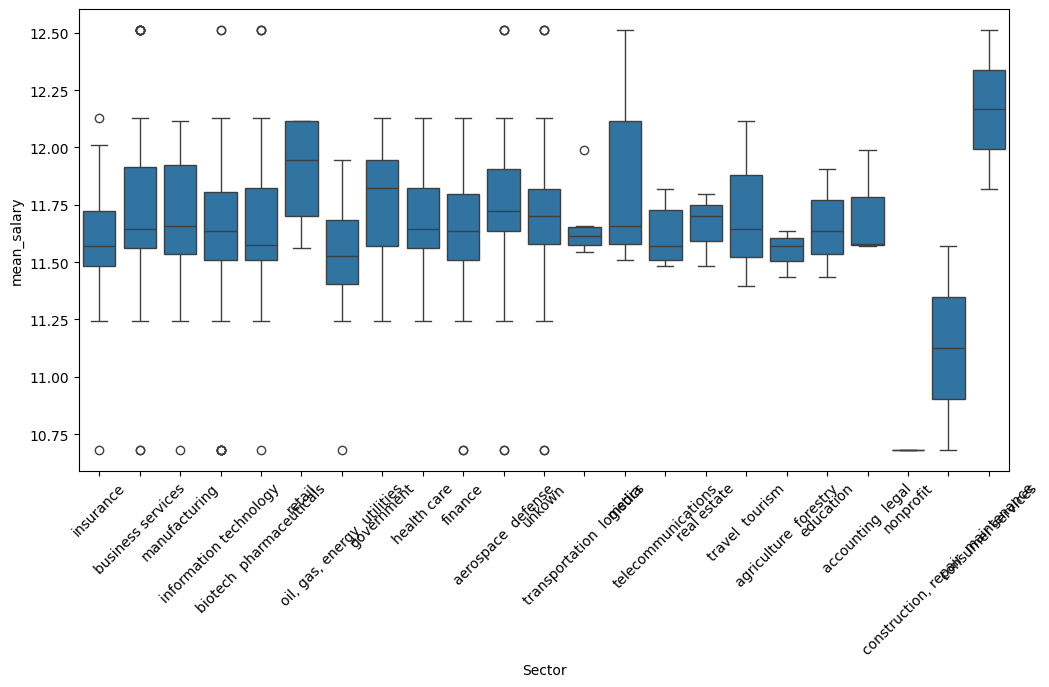

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x="Sector", y="mean_salary", data=df)
plt.xticks(rotation=45)
plt.show()

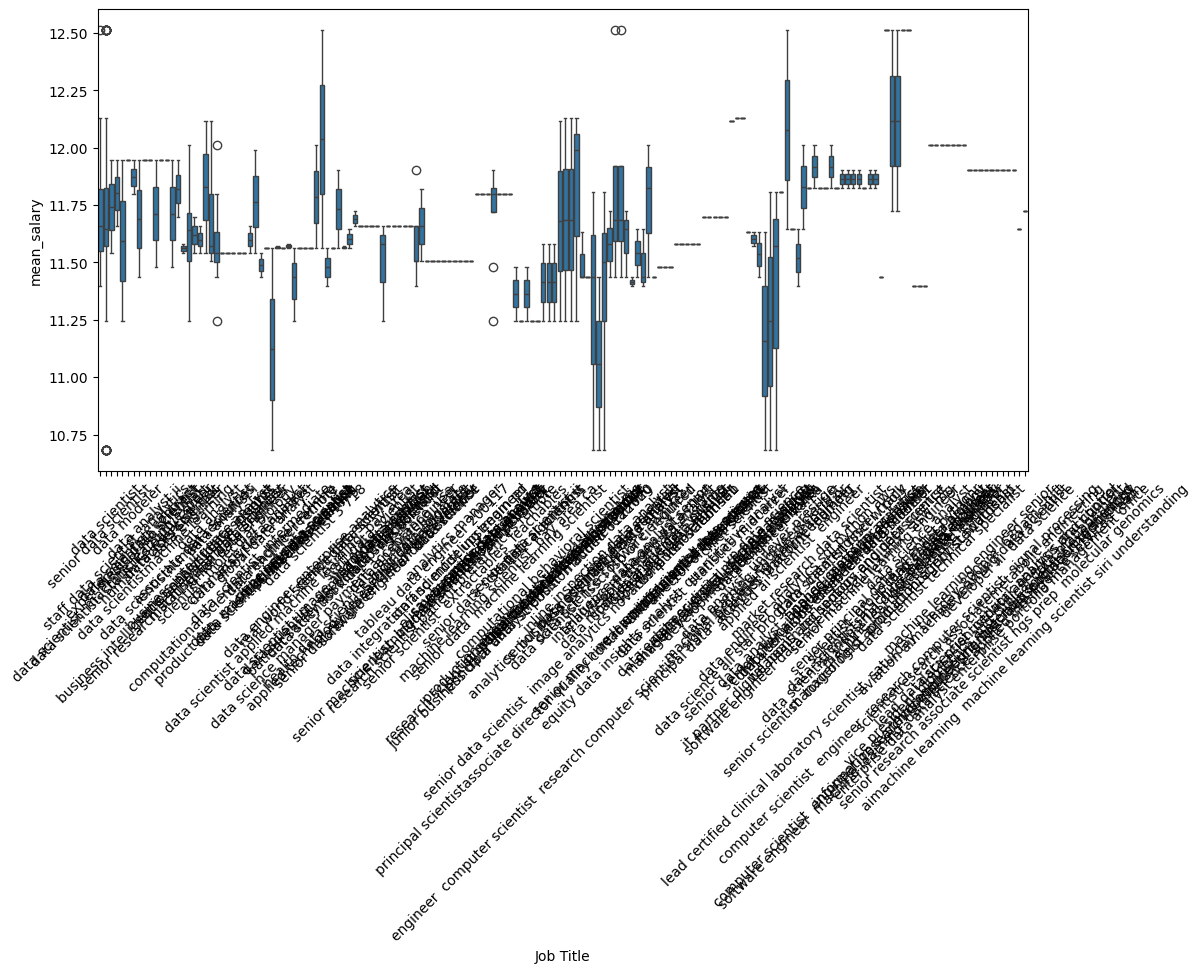

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Job Title", y="mean_salary", data=df)
plt.xticks(rotation=45)
plt.show()

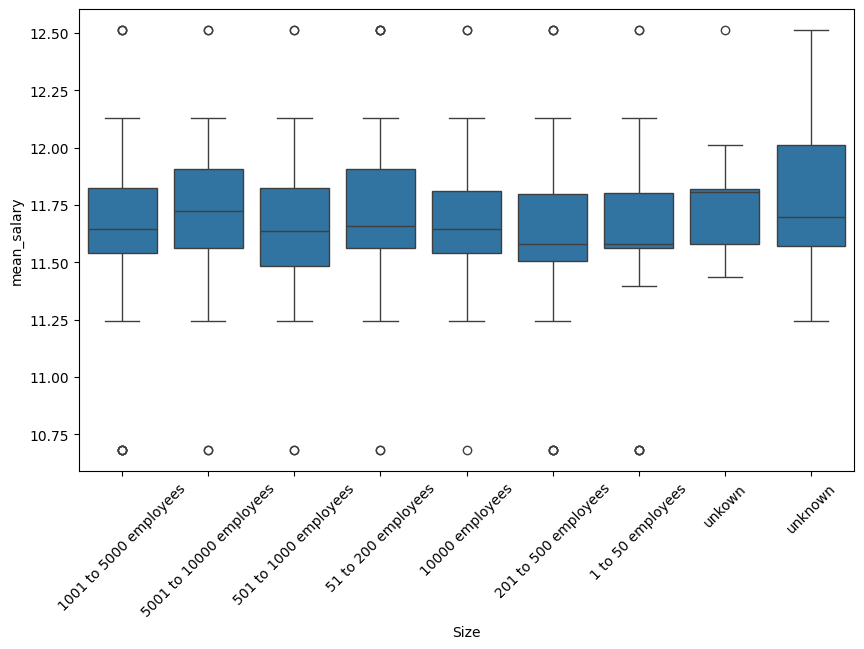

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Size", y="mean_salary", data=df)
plt.xticks(rotation=45)
plt.show()

In [20]:
df.head(5)

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,mean_salary
0,0,senior data scientist,137-171,descriptionthe senior data scientist is respon...,3.1,healthfirst3.1,"new york, ny","new york, ny",1001 to 5000 employees,1993.0,nonprofit organization,insurance carriers,insurance,unknown nonapplicable,"emblemhealth, unitedhealth group, aetna",11.944708
1,1,data scientist,137-171,"secure our nation, ignite your futurejoin the ...",4.2,mantech4.2,"chantilly, va","herndon, va",5001 to 10000 employees,1968.0,company public,research development,business services,1 to 2 billion usd,NaN,11.944708
2,2,data scientist,137-171,overviewanalysis group is one of the largest i...,3.8,analysis group3.8,"boston, ma","boston, ma",1001 to 5000 employees,1981.0,private practice firm,consulting,business services,100 to 500 million usd,NaN,11.944708
3,3,data scientist,137-171,job descriptiondo you have a passion for data ...,3.5,inficon3.5,"newton, ma","bad ragaz, switzerland",501 to 1000 employees,2000.0,company public,electrical electronic manufacturing,manufacturing,100 to 500 million usd,"mks instruments, pfeiffer vacuum, agilent tech...",11.944708
4,4,data scientist,137-171,data scientistaffinity solutions marketing cl...,2.9,affinity solutions2.9,"new york, ny","new york, ny",51 to 200 employees,1998.0,company private,advertising marketing,business services,unknown nonapplicable,"commerce signals, cardlytics, yodlee",11.944708


In [21]:
cleaned_data = df.drop(columns=["Salary Estimate","Rating", "Location", "Headquarters", "Competitors", "index", "Founded"])

In [22]:
cleaned_data.head(5)

,Job Title,Job Description,Company Name,Size,Type of ownership,Industry,Sector,Revenue,mean_salary
0,senior data scientist,descriptionthe senior data scientist is respon...,healthfirst3.1,1001 to 5000 employees,nonprofit organization,insurance carriers,insurance,unknown nonapplicable,11.944708
1,data scientist,"secure our nation, ignite your futurejoin the ...",mantech4.2,5001 to 10000 employees,company public,research development,business services,1 to 2 billion usd,11.944708
2,data scientist,overviewanalysis group is one of the largest i...,analysis group3.8,1001 to 5000 employees,private practice firm,consulting,business services,100 to 500 million usd,11.944708
3,data scientist,job descriptiondo you have a passion for data ...,inficon3.5,501 to 1000 employees,company public,electrical electronic manufacturing,manufacturing,100 to 500 million usd,11.944708
4,data scientist,data scientistaffinity solutions marketing cl...,affinity solutions2.9,51 to 200 employees,company private,advertising marketing,business services,unknown nonapplicable,11.944708


In [25]:
path = "/Users/miriambenali/Desktop/Project-Simplon/HR-pulse-ai-platform/data/cleaned_data/cleaned_data.csv"

cleaned_data.to_csv(path, index=False)